In [1]:
from datasetEmociones import *
from transformer import *
from torch.utils.data import Dataset, DataLoader
import numpy as np
from utils import *
import matplotlib.pyplot as plt

In [2]:
train_transformer_dataset = EmotionDataset(ANNOTATIONS_FILE,
                AUDIO_DIR, 
                data_portion='train',
                transform=log_mel_transform
                )

val_transformer_dataset = EmotionDataset(ANNOTATIONS_FILE,
                AUDIO_DIR, 
                data_portion='validation',
                transform=log_mel_transform
                )

Época: 1
LOSS train 16.41292953491211 valid 12.739737510681152
Modelo guardado en epoca 1
Época: 2
LOSS train 10.060194969177246 valid 7.523353099822998
Modelo guardado en epoca 2
Época: 3
LOSS train 5.8115973472595215 valid 3.899712324142456
Modelo guardado en epoca 3
Época: 4
LOSS train 2.9245758056640625 valid 1.9090722799301147
Modelo guardado en epoca 4
Época: 5
LOSS train 1.5499564409255981 valid 1.192854642868042
Modelo guardado en epoca 5
Época: 6
LOSS train 1.1227614879608154 valid 1.0359597206115723
Modelo guardado en epoca 6
Época: 7
LOSS train 1.0190423727035522 valid 1.0161718130111694
Modelo guardado en epoca 7
Época: 8
LOSS train 1.0040086507797241 valid 1.015405297279358
Modelo guardado en epoca 8
Época: 9
LOSS train 1.0007755756378174 valid 1.0141987800598145
Modelo guardado en epoca 9
Época: 10
LOSS train 1.0023691654205322 valid 1.015434741973877
Época: 11
LOSS train 0.9998164176940918 valid 1.0238522291183472
Época: 12
LOSS train 0.9988172054290771 valid 1.013823628

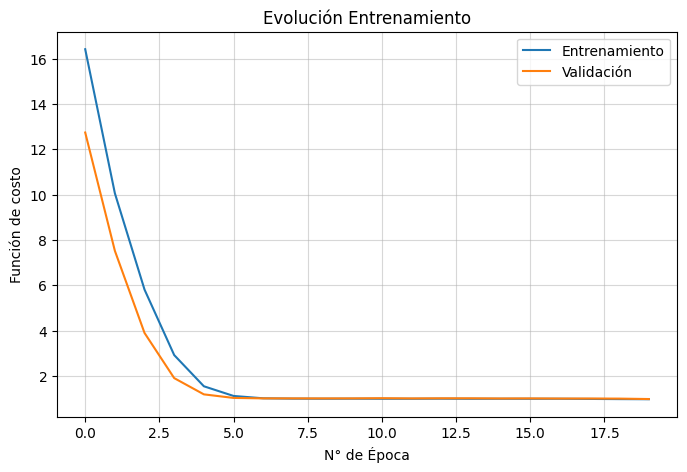

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# modelo
model = MelTransformer(D_pos_emb=50, nhead=1).to(device)

# hiperparámetros
learning_rate = 1e-4
batch_size = 64
epochs = 20

# nombre de archivo con parametros
parameters_file = 'MelTransformer_params_50_1.pt'

# funcion de perdida
loss_fn = nn.MSELoss()

# optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# dataloaders
train_dataloader = DataLoader(train_transformer_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_transformer_dataset, batch_size=batch_size, shuffle=True)

# listas para almacenar la evolución del loss en train y validacion
train_loss_evol = []
val_loss_evol = []

# se inicializan variables del entrenamiento
best_vloss = np.inf

# loop de entrenamiento
for epoch in range(epochs):
    print(f'Época: {epoch + 1}')

    # se realiza el entrenamiento
    model.train()
    avg_loss = train_one_epoch(model, train_dataloader, optimizer, loss_fn, device)

    # se evalua el modelo en validacion
    model.eval()
    avg_vloss = get_val_loss(model, val_dataloader, loss_fn, device)

    # se guardan e imprimen los loss de entrenamiento y validacion
    train_loss_evol.append(avg_loss)
    val_loss_evol.append(avg_vloss)
    print(f'LOSS train {avg_loss} valid {avg_vloss}')

    # se guarda el mejor modelo considerando la loss en validacion
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        # se guardan los parametros con menor loss en validacion
        torch.save(model.state_dict(), parameters_file)
        print(f'Modelo guardado en epoca {epoch+1}')

# se grafica la evolucion de la funcion de costo a lo largo de las epocas
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(train_loss_evol, label = 'Entrenamiento')
ax.plot(val_loss_evol, label = 'Validación')
ax.set(xlabel='N° de Época', ylabel='Función de costo', title='Evolución Entrenamiento')
ax.grid(alpha = 0.5)
ax.legend()
plt.show()

Época: 1
LOSS train 17.94442367553711 valid 15.055108070373535
Modelo guardado en epoca 1
Época: 2
LOSS train 12.356826782226562 valid 9.82861042022705
Modelo guardado en epoca 2
Época: 3
LOSS train 7.929365634918213 valid 5.8021135330200195
Modelo guardado en epoca 3
Época: 4
LOSS train 4.573604583740234 valid 3.07531476020813
Modelo guardado en epoca 4
Época: 5
LOSS train 2.466675281524658 valid 1.6627449989318848
Modelo guardado en epoca 5
Época: 6
LOSS train 1.4513345956802368 valid 1.1272554397583008
Modelo guardado en epoca 6
Época: 7
LOSS train 1.0945137739181519 valid 1.0053937435150146
Modelo guardado en epoca 7
Época: 8
LOSS train 1.0035057067871094 valid 1.009210467338562
Época: 9
LOSS train 0.9965739250183105 valid 1.0112102031707764
Época: 10
LOSS train 0.98271644115448 valid 0.9980435371398926
Modelo guardado en epoca 10
Época: 11
LOSS train 0.9842956066131592 valid 0.9906104207038879
Modelo guardado en epoca 11
Época: 12
LOSS train 0.9731075167655945 valid 0.970962107181

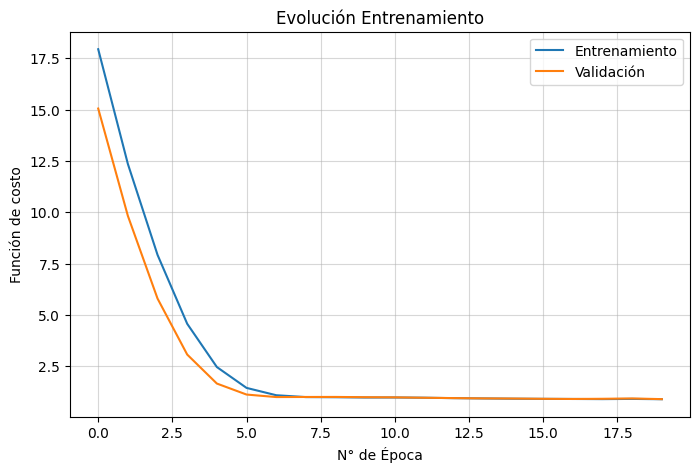

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# modelo
model = MelTransformer(D_pos_emb=50, nhead=2).to(device)

# hiperparámetros
learning_rate = 1e-4
batch_size = 64
epochs = 20

# nombre de archivo con parametros
parameters_file = 'MelTransformer_params_50_2.pt'

# funcion de perdida
loss_fn = nn.MSELoss()

# optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# dataloaders
train_dataloader = DataLoader(train_transformer_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_transformer_dataset, batch_size=batch_size, shuffle=True)

# listas para almacenar la evolución del loss en train y validacion
train_loss_evol = []
val_loss_evol = []

# se inicializan variables del entrenamiento
best_vloss = np.inf

# loop de entrenamiento
for epoch in range(epochs):
    print(f'Época: {epoch + 1}')

    # se realiza el entrenamiento
    model.train()
    avg_loss = train_one_epoch(model, train_dataloader, optimizer, loss_fn, device)

    # se evalua el modelo en validacion
    model.eval()
    avg_vloss = get_val_loss(model, val_dataloader, loss_fn, device)

    # se guardan e imprimen los loss de entrenamiento y validacion
    train_loss_evol.append(avg_loss)
    val_loss_evol.append(avg_vloss)
    print(f'LOSS train {avg_loss} valid {avg_vloss}')

    # se guarda el mejor modelo considerando la loss en validacion
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        # se guardan los parametros con menor loss en validacion
        torch.save(model.state_dict(), parameters_file)
        print(f'Modelo guardado en epoca {epoch+1}')

# se grafica la evolucion de la funcion de costo a lo largo de las epocas
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(train_loss_evol, label = 'Entrenamiento')
ax.plot(val_loss_evol, label = 'Validación')
ax.set(xlabel='N° de Época', ylabel='Función de costo', title='Evolución Entrenamiento')
ax.grid(alpha = 0.5)
ax.legend()
plt.show()

Época: 1
LOSS train 14.224761009216309 valid 10.667139053344727
Modelo guardado en epoca 1
Época: 2
LOSS train 8.31877326965332 valid 5.873022556304932
Modelo guardado en epoca 2
Época: 3
LOSS train 4.233646869659424 valid 2.4989795684814453
Modelo guardado en epoca 3
Época: 4
LOSS train 1.8725310564041138 valid 1.2338122129440308
Modelo guardado en epoca 4
Época: 5
LOSS train 1.1329643726348877 valid 1.014023780822754
Modelo guardado en epoca 5
Época: 6
LOSS train 1.009986162185669 valid 1.014815330505371
Época: 7
LOSS train 0.9961524605751038 valid 1.0096702575683594
Modelo guardado en epoca 7
Época: 8
LOSS train 0.9876651167869568 valid 1.0087878704071045
Modelo guardado en epoca 8
Época: 9
LOSS train 0.9855104088783264 valid 1.0042014122009277
Modelo guardado en epoca 9
Época: 10
LOSS train 0.9862256050109863 valid 0.9990337491035461
Modelo guardado en epoca 10
Época: 11
LOSS train 0.9754712581634521 valid 0.9881131052970886
Modelo guardado en epoca 11
Época: 12
LOSS train 0.968967

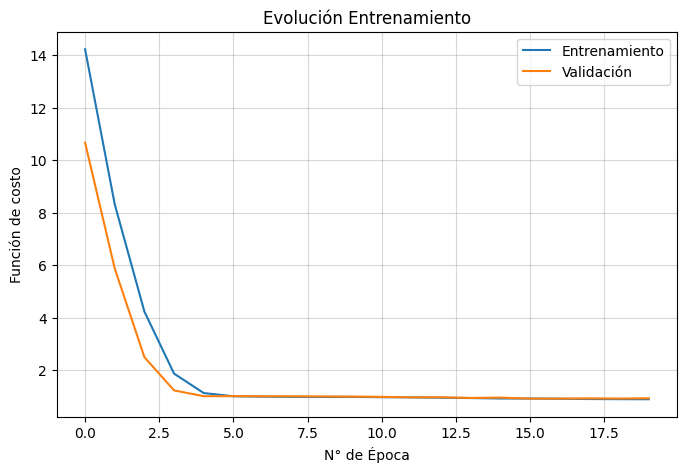

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# modelo
model = MelTransformer(D_pos_emb=50, nhead=10).to(device)

# hiperparámetros
learning_rate = 1e-4
batch_size = 64
epochs = 20

# nombre de archivo con parametros
parameters_file = 'MelTransformer_params_50_10.pt'

# funcion de perdida
loss_fn = nn.MSELoss()

# optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# dataloaders
train_dataloader = DataLoader(train_transformer_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_transformer_dataset, batch_size=batch_size, shuffle=True)

# listas para almacenar la evolución del loss en train y validacion
train_loss_evol = []
val_loss_evol = []

# se inicializan variables del entrenamiento
best_vloss = np.inf

# loop de entrenamiento
for epoch in range(epochs):
    print(f'Época: {epoch + 1}')

    # se realiza el entrenamiento
    model.train()
    avg_loss = train_one_epoch(model, train_dataloader, optimizer, loss_fn, device)

    # se evalua el modelo en validacion
    model.eval()
    avg_vloss = get_val_loss(model, val_dataloader, loss_fn, device)

    # se guardan e imprimen los loss de entrenamiento y validacion
    train_loss_evol.append(avg_loss)
    val_loss_evol.append(avg_vloss)
    print(f'LOSS train {avg_loss} valid {avg_vloss}')

    # se guarda el mejor modelo considerando la loss en validacion
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        # se guardan los parametros con menor loss en validacion
        torch.save(model.state_dict(), parameters_file)
        print(f'Modelo guardado en epoca {epoch+1}')

# se grafica la evolucion de la funcion de costo a lo largo de las epocas
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(train_loss_evol, label = 'Entrenamiento')
ax.plot(val_loss_evol, label = 'Validación')
ax.set(xlabel='N° de Época', ylabel='Función de costo', title='Evolución Entrenamiento')
ax.grid(alpha = 0.5)
ax.legend()
plt.show()

Época: 1
LOSS train 15.696145057678223 valid 12.181772232055664
Modelo guardado en epoca 1
Época: 2
LOSS train 9.559317588806152 valid 6.9966301918029785
Modelo guardado en epoca 2
Época: 3
LOSS train 5.231605052947998 valid 3.402062177658081
Modelo guardado en epoca 3
Época: 4
LOSS train 2.45359468460083 valid 1.5338797569274902
Modelo guardado en epoca 4
Época: 5
LOSS train 1.2655340433120728 valid 1.0406789779663086
Modelo guardado en epoca 5
Época: 6
LOSS train 1.017849326133728 valid 1.0102344751358032
Modelo guardado en epoca 6
Época: 7
LOSS train 0.9935375452041626 valid 1.0056143999099731
Modelo guardado en epoca 7
Época: 8
LOSS train 0.9941024780273438 valid 1.0065850019454956
Época: 9
LOSS train 0.9917953014373779 valid 1.0008776187896729
Modelo guardado en epoca 9
Época: 10
LOSS train 0.9835196733474731 valid 0.99371737241745
Modelo guardado en epoca 10
Época: 11
LOSS train 0.9808303117752075 valid 0.9926206469535828
Modelo guardado en epoca 11
Época: 12
LOSS train 0.9709436

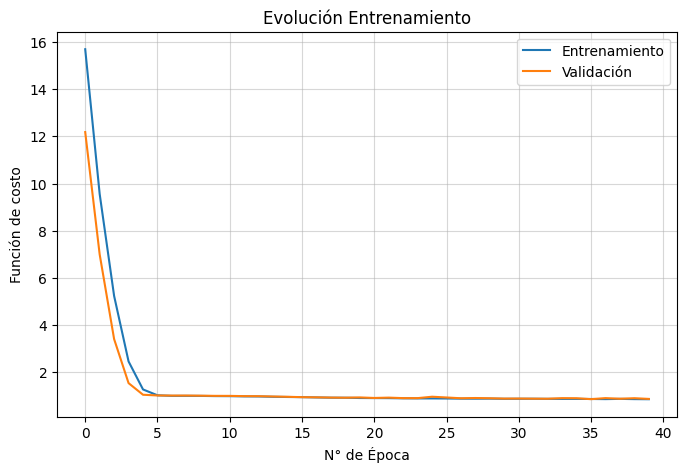

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# modelo
model = MelTransformer(D_pos_emb=50, nhead=25).to(device)

# hiperparámetros
learning_rate = 1e-4
batch_size = 64
epochs = 40

# nombre de archivo con parametros
parameters_file = 'MelTransformer_params_50_25.pt'

# funcion de perdida
loss_fn = nn.MSELoss()

# optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# dataloaders
train_dataloader = DataLoader(train_transformer_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_transformer_dataset, batch_size=batch_size, shuffle=True)

# listas para almacenar la evolución del loss en train y validacion
train_loss_evol = []
val_loss_evol = []

# se inicializan variables del entrenamiento
best_vloss = np.inf

# loop de entrenamiento
for epoch in range(epochs):
    print(f'Época: {epoch + 1}')

    # se realiza el entrenamiento
    model.train()
    avg_loss = train_one_epoch(model, train_dataloader, optimizer, loss_fn, device)

    # se evalua el modelo en validacion
    model.eval()
    avg_vloss = get_val_loss(model, val_dataloader, loss_fn, device)

    # se guardan e imprimen los loss de entrenamiento y validacion
    train_loss_evol.append(avg_loss)
    val_loss_evol.append(avg_vloss)
    print(f'LOSS train {avg_loss} valid {avg_vloss}')

    # se guarda el mejor modelo considerando la loss en validacion
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        # se guardan los parametros con menor loss en validacion
        torch.save(model.state_dict(), parameters_file)
        print(f'Modelo guardado en epoca {epoch+1}')

# se grafica la evolucion de la funcion de costo a lo largo de las epocas
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(train_loss_evol, label = 'Entrenamiento')
ax.plot(val_loss_evol, label = 'Validación')
ax.set(xlabel='N° de Época', ylabel='Función de costo', title='Evolución Entrenamiento')
ax.grid(alpha = 0.5)
ax.legend()
plt.show()